Graph Isomorphism Network 

In [1]:
import torch
from torch_geometric.data import Data
import os

# Define the path where the patient graphs are stored
graphs_dir = '../PreprocessingScripts/PatientGraphs/StaticEdge/'

# Initialize a dictionary to store the graphs
patient_graphs = {}

# Loop through the files in the directory and load each graph
for file_name in os.listdir(graphs_dir):
    if file_name.endswith('.pt'):
        # Get the patient identifier (e.g., 'patient_1', 'patient_2', etc.)
        patient_id = file_name.split('.')[0]
        
        # Load the graph (PyTorch Geometric graph object)
        graph = torch.load(os.path.join(graphs_dir, file_name))
        
        # Add the graph to the dictionary
        patient_graphs[patient_id] = graph
        #print(graph.edge_attr.shape)

# Now `patient_graphs` contains all the loaded graphs, accessible by patient IDs


/tmp/ipykernel_2903098/1231427283.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  graph = torch.load(os.path.join(graphs_dir, file_name))


GIN module 

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv
from torch_geometric.nn import global_add_pool
from torch_geometric.data import Batch

class MultiheadAttentionPooling(nn.Module):
    """Self-attention-based pooling similar to Set Transformer"""
    def __init__(self, in_dim, num_heads=4):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=in_dim, num_heads=num_heads, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, in_dim))  # Learnable query vector

    def forward(self, x, batch):
        """Handles both batched and single graphs"""
        if batch is None:
            return x.mean(dim=0, keepdim=True)  # Fallback to mean pooling for single graphs

        batch_size = batch.max().item() + 1
        pooled_embeddings = []

        for i in range(batch_size):
            node_embeddings = x[batch == i]  
            query = self.query.expand(node_embeddings.size(0), -1, -1)
            attn_output, _ = self.attention(query, node_embeddings.unsqueeze(0), node_embeddings.unsqueeze(0))
            pooled_embeddings.append(attn_output.mean(dim=1))

        return torch.cat(pooled_embeddings, dim=0)

class GIN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GIN, self).__init__()
        
        self.mlp1 = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        
        self.mlp2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels)  
        )
        
        self.gin1 = GINConv(self.mlp1)
        self.gin2 = GINConv(self.mlp2)

        self.attn_pool = MultiheadAttentionPooling(out_channels, num_heads=8)

    def forward(self, x, edge_index, batch=None):
        x = self.gin1(x, edge_index).relu()
        x = self.gin2(x, edge_index)

        x = self.attn_pool(x, batch)  

        return x.squeeze(0)

def generate_graph_embeddings(patient_graphs, in_channels, hidden_channels, out_channels):
    embeddings = []
    model = GIN(in_channels, hidden_channels, out_channels)
    model.eval()

    for patient, graph in patient_graphs.items():
        x, edge_index = graph.x, graph.edge_index
        batch = getattr(graph, 'batch', None)  # Check if batch exists

        with torch.no_grad():
            graph_embedding = model(x, edge_index, batch).cpu().numpy()

        embeddings.append(graph_embedding)

    return embeddings

in_channels = 1 
hidden_channels = 128
out_channels = 128

# Now generating the embeddings with the updated function
embeddings = generate_graph_embeddings(patient_graphs, in_channels, hidden_channels, out_channels)

In [11]:
print(embeddings[0].shape)

(128,)


Now lets implement some clustering methods 
These will be the same across all GNN models 

1. K-Means clustering

In [12]:
from sklearn.cluster import KMeans
import numpy as np

def kmeans_clustering(embeddings, n_clusters=3):
    # Convert embeddings to numpy array
    embeddings = np.array(embeddings)
    
    # Initialize KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    
    # Fit the model
    kmeans.fit(embeddings)
    
    # Get cluster labels
    labels = kmeans.labels_
    
    return labels

# Example usage
n_clusters = 3  # Set the desired number of clusters
kmeans_labels = kmeans_clustering(embeddings, n_clusters)
print(kmeans_labels)


[2 0 1 1 2 0 1 1 2 2 2 1 2 0 1 2 2 2 2 1 2 2 0 1 0 1 1 0 0 1 1 2 0 2 0 1 0
 1 1 2 0 2 1 1 1 1 1 0 0 2 2 2 2 1 2 0 1 0 2 2 1 1 1 0 2 0 1 1 2 1 1 2 1 1
 0]


In [ ]:
import re

patient_ids = list(patient_graphs.keys())
cluster_dict = {}

# Iterate over the cluster labels and patient IDs
for idx, cluster in enumerate(kmeans_labels):
    patient_id = patient_ids[idx]
    if cluster not in cluster_dict:
        cluster_dict[cluster] = []
    cluster_dict[cluster].append(patient_id)

# Print the clusters and corresponding patient IDs
for cluster, patients in sorted(cluster_dict.items()):
    print(f"Cluster {cluster}:")
    # Sort the patients within the cluster based on the numeric part of the patient ID
    sorted_patients = sorted(patients, key=lambda x: int(re.search(r'\d+', x).group()))
    
    for patient in sorted_patients:
        # Extract the numeric part of the patient ID (e.g., 'patient_22' -> '22')
        patient_number = re.search(r'\d+', patient).group()  # Extract numeric part only
        print(f"  Sample {patient_number}")  # Print without '_graph' part
    print()


Cluster 0:
  Sample 4
  Sample 9
  Sample 19
  Sample 22
  Sample 26
  Sample 30
  Sample 48
  Sample 53
  Sample 55
  Sample 60
  Sample 62
  Sample 70
  Sample 72
  Sample 74
  Sample 85
  Sample 88
  Sample 89
  Sample 96

Cluster 1:
  Sample 2
  Sample 3
  Sample 5
  Sample 6
  Sample 7
  Sample 8
  Sample 10
  Sample 11
  Sample 12
  Sample 13
  Sample 14
  Sample 15
  Sample 16
  Sample 17
  Sample 18
  Sample 20
  Sample 21
  Sample 23
  Sample 24
  Sample 25
  Sample 43
  Sample 45
  Sample 47
  Sample 49
  Sample 63
  Sample 75
  Sample 86
  Sample 91
  Sample 92
  Sample 93
  Sample 94

Cluster 2:
  Sample 1
  Sample 29
  Sample 32
  Sample 33
  Sample 34
  Sample 36
  Sample 37
  Sample 38
  Sample 39
  Sample 41
  Sample 50
  Sample 54
  Sample 61
  Sample 64
  Sample 66
  Sample 69
  Sample 73
  Sample 76
  Sample 77
  Sample 78
  Sample 79
  Sample 80
  Sample 81
  Sample 82
  Sample 83
  Sample 87



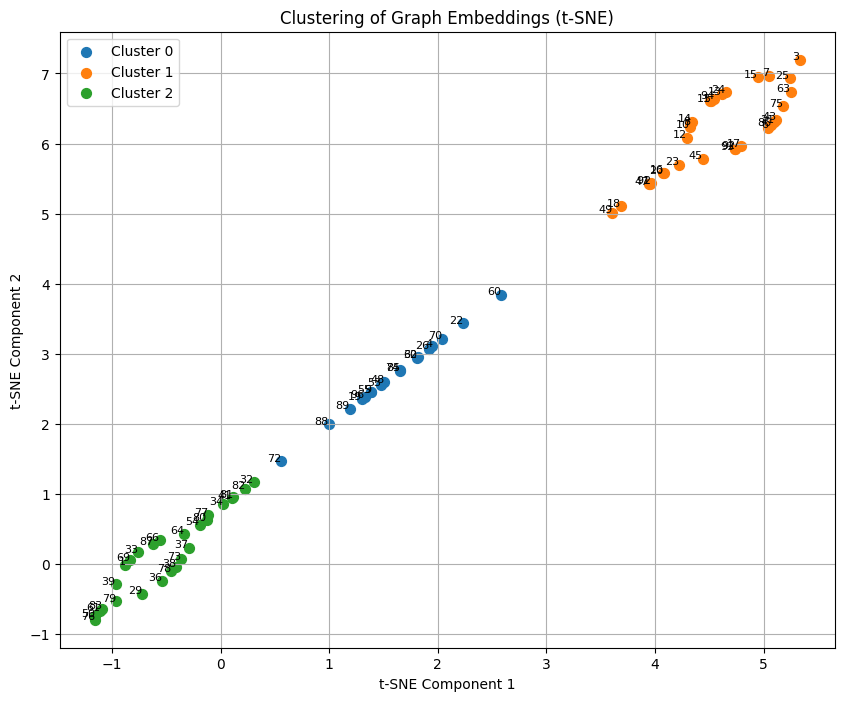

In [16]:
import re
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np 

def plot_clusters(embeddings, labels, patient_ids, n_clusters=3, annotate=True):
    embeddings = np.array(embeddings)

    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)

    # Plot the clusters
    plt.figure(figsize=(10, 8))

    for cluster in range(n_clusters):
        cluster_indices = np.where(labels == cluster)[0]
        plt.scatter(reduced_embeddings[cluster_indices, 0], reduced_embeddings[cluster_indices, 1], label=f'Cluster {cluster}', s=50)

        if annotate:
            for i in cluster_indices:
                patient_number = re.search(r'\d+', patient_ids[i]).group()
                plt.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], patient_number, fontsize=8, ha='right')

    plt.title('Clustering of Graph Embeddings (t-SNE)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Get the ordered patient IDs
patient_ids = list(patient_graphs.keys())

# Example usage
plot_clusters(embeddings, kmeans_labels, patient_ids, n_clusters)


Affinity propagation clustering

In [13]:
import numpy as np
from sklearn.cluster import AffinityPropagation

def affinity_propagation_clustering(embeddings):
    # Convert embeddings to NumPy array and ensure it's 2D
    embeddings = np.array(embeddings)
    if len(embeddings.shape) == 1:
        embeddings = embeddings.reshape(-1, 1)  # Reshape if needed
    
    # Initialize and fit Affinity Propagation
    affinity_propagation = AffinityPropagation(random_state=42)
    labels = affinity_propagation.fit_predict(embeddings)

    # Get the number of clusters
    n_clusters = len(set(labels))

    print(f"Clusters found: {n_clusters}")
    
    return labels

# Example usage
affinity_labels = affinity_propagation_clustering(embeddings)
print("Cluster labels:", affinity_labels)


Clusters found: 5
Cluster labels: [1 0 2 3 4 0 2 3 4 1 1 2 4 0 2 1 1 4 4 2 1 4 0 2 0 2 2 0 4 2 3 4 0 1 0 2 0
 3 2 4 0 4 3 2 3 2 2 3 0 4 4 4 1 2 4 0 3 0 1 4 2 2 3 0 4 0 2 2 1 2 2 4 2 3
 0]


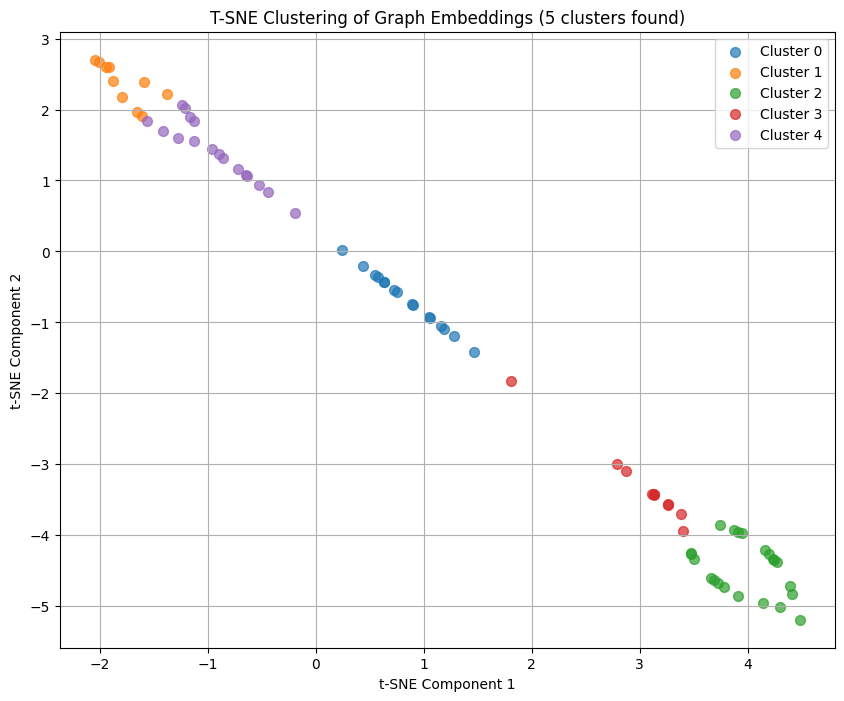

In [14]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne_clusters(embeddings, labels):
    # Convert embeddings to a NumPy array if they are not already
    embeddings = np.array(embeddings)

    # Reduce dimensionality to 2D using t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)

    # Get unique labels
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    # Plot the clusters
    plt.figure(figsize=(10, 8))
    
    # Loop over each cluster and plot
    for label in unique_labels:
        cluster_indices = np.where(labels == label)[0]

        if label == -1:
            plt.scatter(
                reduced_embeddings[cluster_indices, 0], 
                reduced_embeddings[cluster_indices, 1], 
                label="Noise (Outliers)", 
                c="black", s=50, alpha=0.5, marker="x"
            )
        else:
            plt.scatter(
                reduced_embeddings[cluster_indices, 0], 
                reduced_embeddings[cluster_indices, 1], 
                label=f'Cluster {label}', 
                s=50, alpha=0.7
            )

    plt.title(f'T-SNE Clustering of Graph Embeddings ({n_clusters} clusters found)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Example usage
plot_tsne_clusters(embeddings, affinity_labels)  # Use affinity_labels or any other labels


Gaussian Mixture Model (GMM)

In [22]:
from sklearn.mixture import GaussianMixture

def gmm_clustering(embeddings, n_components=3):
    # Convert embeddings to numpy array
    embeddings = np.array(embeddings)
    
    # Initialize GMM
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    
    # Fit the model
    gmm.fit(embeddings)
    
    # Get cluster labels
    labels = gmm.predict(embeddings)
    
    return labels

# Example usage
gmm_labels = gmm_clustering(embeddings, n_components=3)
print(gmm_labels)


[2 0 1 1 2 0 1 1 2 2 2 1 2 0 1 2 2 2 2 1 2 2 0 1 0 1 1 0 2 1 1 2 0 2 0 1 0
 1 1 2 0 2 1 1 1 1 1 0 0 2 2 2 2 1 2 0 1 0 2 2 1 1 1 0 2 0 1 1 2 1 1 2 1 1
 0]


In [23]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score to evaluate clustering performance
sil_score = silhouette_score(embeddings, gmm_labels)
print(f'Silhouette Score: {sil_score}')


Silhouette Score: 0.6878722906112671


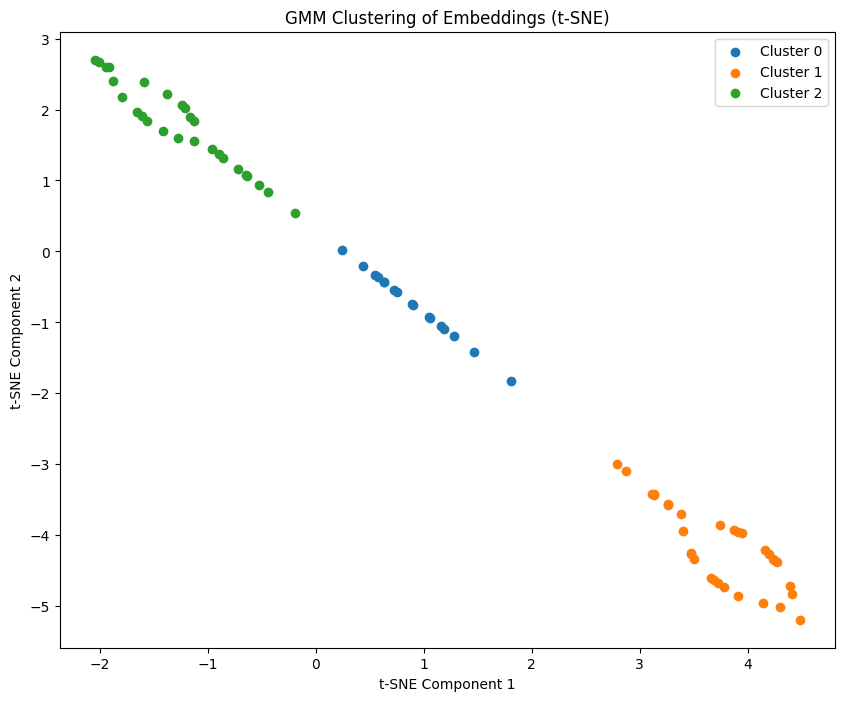

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_gmm_clusters_tsne(embeddings, labels):
    embeddings = np.array(embeddings)

    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))

    unique_labels = set(labels)
    for label in unique_labels:
        cluster_indices = np.where(labels == label)[0]
        plt.scatter(
            reduced_embeddings[cluster_indices, 0], 
            reduced_embeddings[cluster_indices, 1], 
            label=f'Cluster {label}'
        )

    plt.title('GMM Clustering of Embeddings (t-SNE)')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.show()

plot_gmm_clusters_tsne(embeddings, gmm_labels)


Spectral clustering

In [25]:
from sklearn.cluster import SpectralClustering

n_clusters=3

def spectral_clustering(embeddings, n_clusters):
    # Convert embeddings to numpy array
    embeddings = np.array(embeddings)
    
    # Initialize Spectral Clustering
    spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
    
    # Fit the model
    labels = spectral.fit_predict(embeddings)
    
    return labels

# Example usage
spectral_labels = spectral_clustering(embeddings, n_clusters)
print(spectral_labels)


[0 2 1 1 0 2 1 1 0 0 0 1 0 2 1 0 0 0 0 1 0 0 2 1 2 1 1 2 0 1 1 0 2 0 2 1 2
 1 1 0 2 0 1 1 1 1 1 2 2 0 0 0 0 1 0 2 1 2 0 0 1 1 1 2 0 2 1 1 0 1 1 0 1 1
 2]


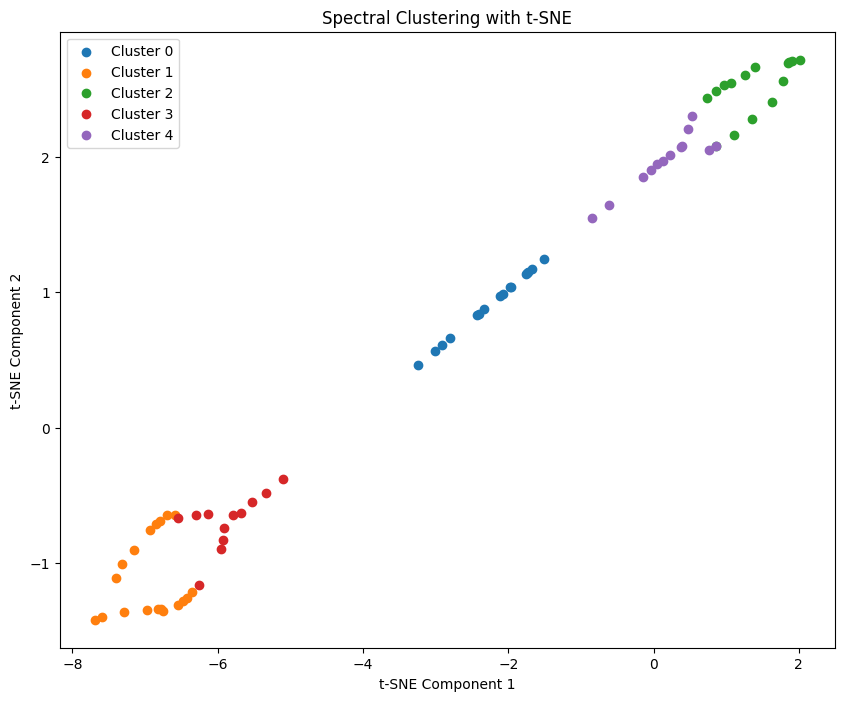

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

def plot_spectral_clustering_tsne(embeddings, labels):
    # Reduce dimensionality to 2D using t-SNE
    embeddings = np.array(embeddings)
    tsne = TSNE(n_components=2, random_state=42)
    reduced_embeddings = tsne.fit_transform(embeddings)
    
    # Plot each cluster
    plt.figure(figsize=(10, 8))
    unique_labels = set(labels)
    for label in unique_labels:
        cluster_indices = np.where(labels == label)[0]
        plt.scatter(
            reduced_embeddings[cluster_indices, 0], 
            reduced_embeddings[cluster_indices, 1], 
            label=f'Cluster {label}'
        )

    plt.title('Spectral Clustering with t-SNE')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend()
    plt.show()

# Example usage
spectral_labels = spectral_clustering(embeddings, n_clusters=5)
plot_spectral_clustering_tsne(embeddings, spectral_labels)


Self-Organizing Maps (SOM) - unsupervised clustering

In [ ]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt

def som_clustering(embeddings, x_size=5, y_size=5, sigma=0.6, learning_rate=0.1, num_iterations=1000):

    embeddings = np.array(embeddings)
    som = MiniSom(x_size, y_size, embeddings.shape[1], sigma=sigma, learning_rate=learning_rate, random_seed=42)
    som.train(embeddings, num_iterations)

    win_map = np.array([som.winner(e) for e in embeddings])

    return win_map
som_labels = som_clustering(embeddings, x_size=5, y_size=5)
print(som_labels)
unique_clusters = len(np.unique(som_labels, axis=0))
print(f'Number of unique clusters identified: {unique_clusters}')
import numpy as np
import matplotlib.pyplot as plt

def plot_som_clusters(embeddings, som_labels):
    embeddings = np.array(embeddings)  # Ensure embeddings are a NumPy array

    plt.figure(figsize=(10, 8))

    # Map each point to its corresponding cluster in the SOM grid
    for i, label in enumerate(som_labels):
        cluster_index = label[0]  # Extract the first element of the tuple as the cluster index
        plt.scatter(embeddings[i, 0], embeddings[i, 1], c=f'C{cluster_index}', label=f'Cluster {cluster_index}', alpha=0.5)

    plt.title('SOM Clustering of Embeddings')
    plt.xlabel('Embedding Dimension 1')
    plt.ylabel('Embedding Dimension 2')
    plt.legend()
    plt.show()

# Example usage
plot_som_clusters(embeddings, som_labels)
